In [ ]:

from skimage import data, io
from matplotlib import pyplot as plt
import numpy as np
from skimage import data
from scipy.ndimage import median_filter

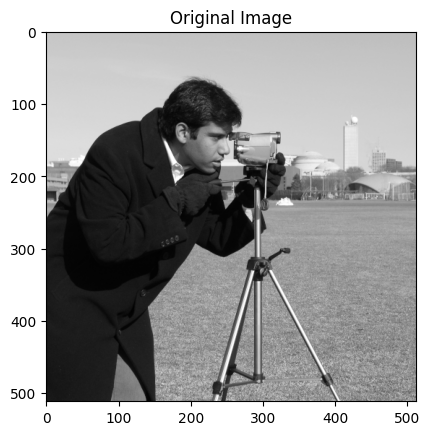

In [ ]:
# Load a gray scale image
img = data.camera()
plt.imshow(img , "gray" , vmin=0 , vmax=255)
plt.title("Original Image")
plt.show()

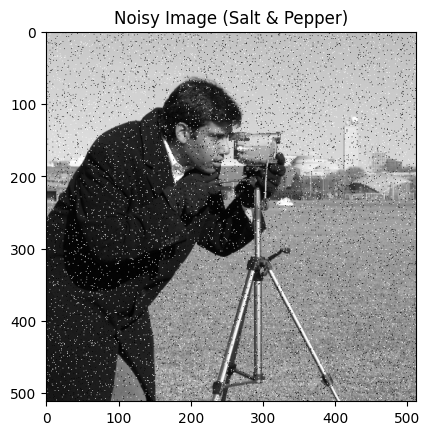

In [ ]:
def add_salt_pepper(image, amount=0.05):
    noisy = image.copy()
    num_pixels = image.size
    num_salt = int(amount * num_pixels / 2)
    num_pepper = int(amount * num_pixels / 2)

    # salt (255)
    coords_salt = (np.random.randint(0, image.shape[0], num_salt),
                   np.random.randint(0, image.shape[1], num_salt))
    noisy[coords_salt] = 255

    # pepper (0)
    coords_pepper = (np.random.randint(0, image.shape[0], num_pepper),
                     np.random.randint(0, image.shape[1], num_pepper))
    noisy[coords_pepper] = 0

    return noisy

noisy = add_salt_pepper(img, amount=0.05)

plt.imshow(noisy, cmap="gray", vmin=0, vmax=255)
plt.title("Noisy Image (Salt & Pepper)")
plt.show()

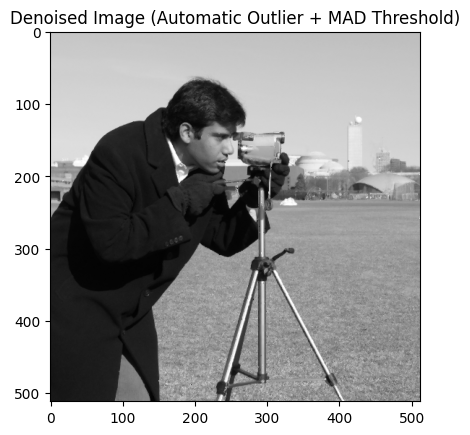

In [ ]:
from scipy.ndimage import median_filter

def auto_outlier_denoise(image, window=3, c=2.5):
    I = image.astype(np.float64)

    # 1) Local median
    med_local = median_filter(I, size=(window, window), mode='reflect')

    # 2) Absolute deviation
    abs_dev = np.abs(I - med_local)

    # 3) Local MAD
    MAD = median_filter(abs_dev, size=(window, window), mode='reflect')

    # 4) Automatic threshold D = c * MAD
    D = c * (MAD + 1e-8)

    # 5) Outlier mask
    mask = abs_dev > D

    # 6) Replace outliers
    out = I.copy()
    out[mask] = med_local[mask]

    return out.astype(image.dtype)

# Apply automatic outlier filter
denoised = auto_outlier_denoise(noisy, window=3, c=2.5)

plt.imshow(denoised, cmap="gray", vmin=0, vmax=255)
plt.title("Denoised Image (Automatic Outlier + MAD Threshold)")
plt.show()